Question One

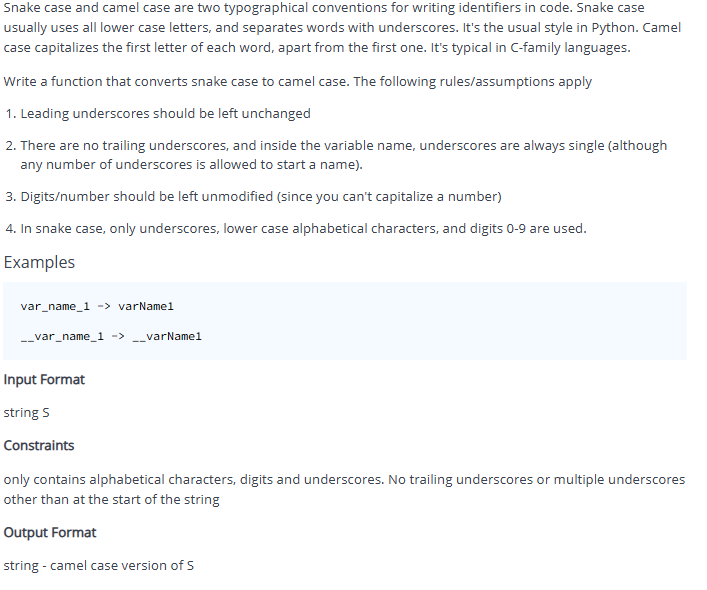

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'SnakeToCamel' function below.
#
# The function is expected to return a STRING.
# The function accepts STRING S as parameter.
#

def SnakeToCamel(S):
   
    # Start counting from the first character
    i = 0

    # Keep moving forward while the character is an underscore "_"
    while i < len(S) and S[i] == '_':
        i += 1

    # Store all leading underscores 
    leading_underscores = S[:i]

    # Store the remaining part of the string after underscores
    rest = S[i:]

    # If there is nothing left after underscores return them as is
    if not rest:
        return leading_underscores

    # Split the remaining string wherever "_" appears
    parts = rest.split('_')

    # The first word stays lowercase 
    camel = parts[0]

    # Go through the remaining words
    for part in parts[1:]:
        # Capitalize each word and add it to the result
        camel += part.capitalize()

    # Combine leading underscores and camelCase word
    return leading_underscores + camel


if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    snake = input()

    camel = SnakeToCamel(snake)

    fptr.write(camel + '\n')

    fptr.close()


Question Two

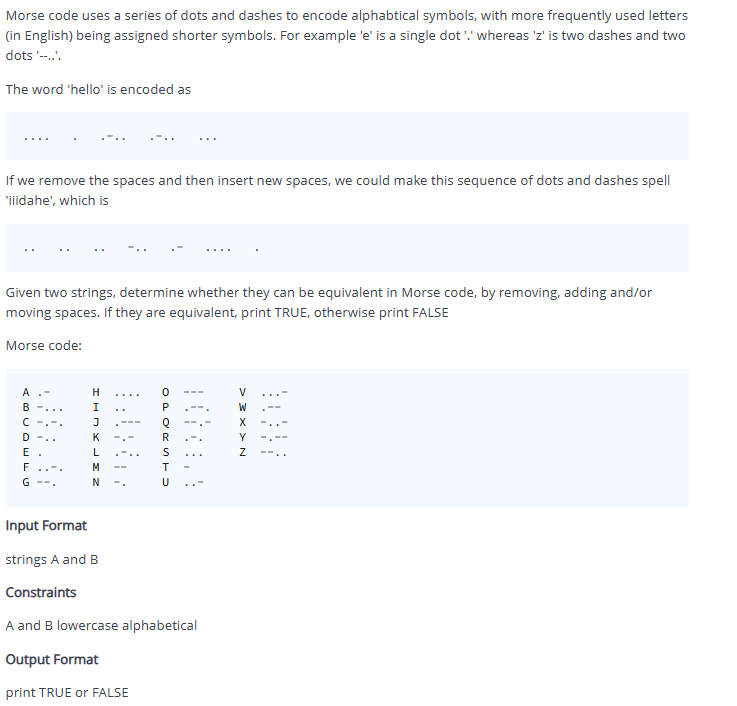

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'MorseEquivalent' function below.
#
# The function accepts following parameters:
#  1. STRING A
#  2. STRING B
#

def MorseEquivalent(A, B):

    # Dictionary mapping each lowercase letter to its Morse code equivalent
    morse = {
        'a': '.-',    'b': '-...',  'c': '-.-.',  'd': '-..',
        'e': '.',     'f': '..-.',  'g': '--.',   'h': '....',
        'i': '..',    'j': '.---',  'k': '-.-',   'l': '.-..',
        'm': '--',    'n': '-.',    'o': '---',   'p': '.--.',
        'q': '--.-',  'r': '.-.',   's': '...',   't': '-',
        'u': '..-',   'v': '...-',  'w': '.--',   'x': '-..-',
        'y': '-.--',  'z': '--..'
    }

    #  convert a string into its Morse code 
    def encode(s):
        # Join Morse codes of each character in the string into one continuous string
        return ''.join(morse[ch] for ch in s)
    # s is the full word 
    #ch is one single letter from the word

    # Compare the Morse code of string A and string B
    if encode(A) == encode(B):
        # Print TRUE if both Morse codes are identical
        print("TRUE")
    else:
        # Print FALSE if the Morse codes are different
        print("FALSE")



if __name__ == '__main__':
    first_multiple_input = input().rstrip().split()

    A = first_multiple_input[0]

    B = first_multiple_input[1]

    MorseEquivalent(A, B)


Question Three

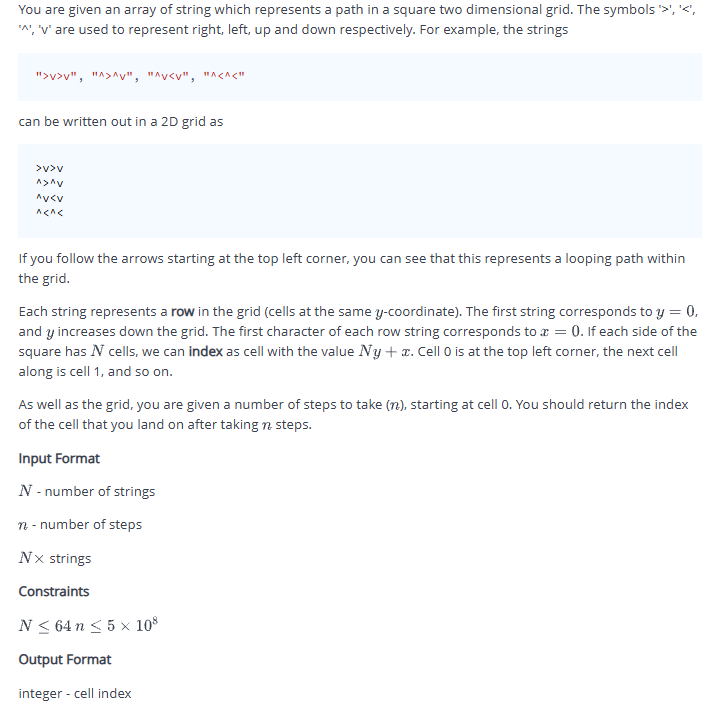

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'TakeSteps' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER nArray
#  2. INTEGER nSteps
#  3. STRING_ARRAY grid
#
def TakeSteps(nArray, nSteps, grid):
    # Total number of cells in the grid 
    total = nArray * nArray

    # List to store where each cell points to next
    nxt = [0] * total

    # Loop through each row
    for r in range(nArray):
        # Loop through each column
        for c in range(nArray):
            # Convert into a single index number
            idx = r * nArray + c

            # Get the direction character in the grid
            ch = grid[r][c]

            # Decide the next cell based on the direction
            if ch == '>':
                nr, nc = r, c + 1      # move right
            elif ch == '<':
                nr, nc = r, c - 1      # move left
            elif ch == '^':
                nr, nc = r - 1, c      # move up
            else:  # 'v'
                nr, nc = r + 1, c      # move down

            # Store the next cell index for this cell
            nxt[idx] = nr * nArray + nc

    # Dictionary to remember when we first visited a cell
    visited = {}

    # List to store the path we travel
    path = []

    # Start from cell 0
    cur = 0

    # Step counter
    step = 0

    # Keep moving until we visit a cell again 
    while cur not in visited:
        visited[cur] = step     # record step number for this cell
        path.append(cur)        # add cell to path
        cur = nxt[cur]          # move to next cell
        step += 1               # increase step count

    # Find where the cycle starts
    cycle_start = visited[cur]

    # Length of the cycle
    cycle_len = step - cycle_start

    # If steps needed is before cycle starts
    if nSteps < step:
        return path[nSteps]
    else:
        # Remove steps before cycle
        nSteps -= cycle_start

          # Keep reducing steps until it fits inside the cycle
        while nSteps >= cycle_len:
            nSteps -= cycle_len

        # Move to the correct position inside the cycle
        return path[cycle_start + nSteps]


if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    nArray = int(input().strip())

    nSteps = int(input().strip())

    grid = []

    for _ in range(nArray):
        grid_item = input()
        grid.append(grid_item)

    finalCellIndex = TakeSteps(nArray, nSteps, grid)

    fptr.write(str(finalCellIndex) + '\n')

    fptr.close()


Question Four

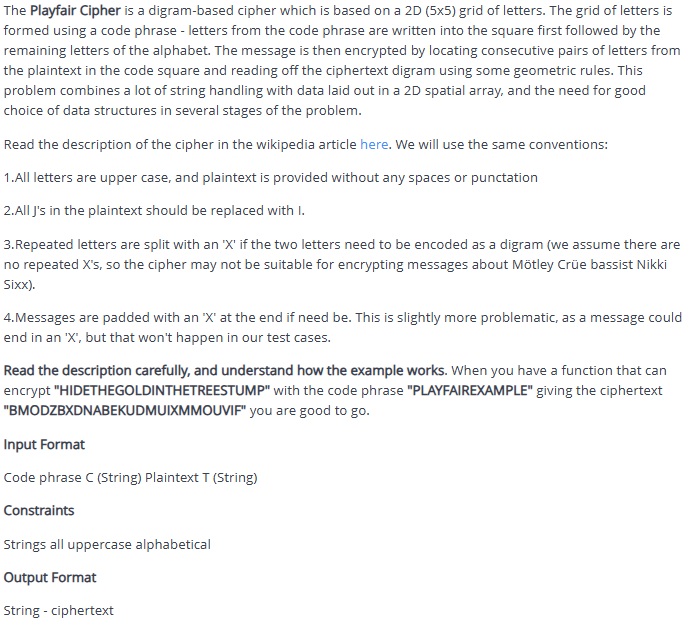

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'PlayfairCode' function below.
#
# The function is expected to return a STRING.
# The function accepts following parameters:
#  1. STRING plainText
#  2. STRING codePhrase
#
def PlayfairCode(plainText, codePhrase):
    # Replace all J's with I's because Playfair uses only 25 letters
    plainText = plainText.replace('J', 'I')
    codePhrase = codePhrase.replace('J', 'I')

    # Create a set to track letters already used in the square
    seen = set()
    # This list will store the 5x5 Playfair square letters
    square = []

    # Add letters from the code phrase to the square 
    for ch in codePhrase:
        if ch not in seen and ch != 'J':
            seen.add(ch)
            square.append(ch)

    # Add remaining letters of the alphabet
    for ch in "ABCDEFGHIKLMNOPQRSTUVWXYZ":
        if ch not in seen:
            seen.add(ch)
            square.append(ch)

    # Create a dictionary to store row and column of each letter
    pos = {}
    for i in range(25):
        # i // 5 gives row number, i % 5 gives column number
        pos[square[i]] = (i // 5, i % 5)

    # List to store pairs of letters 
    digrams = []
    i = 0

    # Loop through plaintext to create digrams
    while i < len(plainText):
        a = plainText[i]
        # Take next letter or use X if at the end
        b = plainText[i + 1] if i + 1 < len(plainText) else 'X'

        # If both letters are the same pair with X
        if a == b:
            digrams.append((a, 'X'))
            i += 1
        else:
            digrams.append((a, b))
            i += 2

    # If the last digram has only one letter add X
    if len(digrams[-1]) == 1:
        digrams[-1] = (digrams[-1][0], 'X')

    # List to store encrypted characters
    cipher = []

    # Encrypt each digram
    for a, b in digrams:
        # Get positions of both letters
        r1, c1 = pos[a]
        r2, c2 = pos[b]

        # If letters are in the same row
        if r1 == r2:
            cipher.append(square[r1 * 5 + (c1 + 1) % 5])
            cipher.append(square[r2 * 5 + (c2 + 1) % 5])

        # else If letters are in the same column
        elif c1 == c2:
            cipher.append(square[((r1 + 1) % 5) * 5 + c1])
            cipher.append(square[((r2 + 1) % 5) * 5 + c2])

        # else letters form a rectangle
        else:
            cipher.append(square[r1 * 5 + c2])
            cipher.append(square[r2 * 5 + c1])

    # Join all encrypted letters into a string and return it
    return ''.join(cipher)


if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    first_multiple_input = input().rstrip().split()

    plainText = first_multiple_input[0]

    codePhrase = first_multiple_input[1]

    cipherText = PlayfairCode(plainText, codePhrase)

    fptr.write(cipherText + '\n')

    fptr.close()
